In [1]:
import numpy as np
import pandas
from IMPtorch.restraints.release import stereochemistry
from IMPtorch.samplers.mcmc import MCMC
from IMPtorch.representations import SystemRepresentation
import torch


print("hello world")

ModuleNotFoundError: No module named 'jaxtyping'

In [2]:
NUM_PARTICLES = 8
particles = SystemRepresentation(
    xyz_ref = torch.FloatTensor(NUM_PARTICLES,3).uniform_(0.1, 100.),
    rigid_body = torch.arange(NUM_PARTICLES),
    super_rigid_body = torch.arange(NUM_PARTICLES)
)

In [3]:
print(particles)

SystemRepresentation(xyz_ref=tensor([[99.6129, 95.3510, 96.0991],
        [10.7198, 54.1940, 32.6080],
        [ 3.9139, 72.9483, 99.7756],
        [28.9903, 46.3287, 37.3185],
        [16.8284, 10.8537, 91.6088],
        [98.4377,  4.8571, 74.3932],
        [94.6347, 81.8997, 54.3407],
        [28.4786, 96.5338, 99.1120]]), xyz_delta=tensor([]), delta_idx=tensor([]), delta_state_idx=tensor([]), state_idx=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), resolutions=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), mass=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), radius=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), volume=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), atom_type=tensor([1, 1, 1, 1, 1, 1, 1, 1], dtype=torch.int32), res_num=tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.int32), ins_code=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), res_name=tensor([7, 7, 7, 7, 7, 7, 7, 7], dtype=torch.int32), fragment_id=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), fragment_start=

coordinates:  [[ 6.55000000e+01  0.00000000e+00  0.00000000e+00]
 [ 4.63154945e+01  4.63154945e+01  0.00000000e+00]
 [-2.86309592e-06  6.55000000e+01  0.00000000e+00]
 [-4.63154945e+01  4.63154945e+01  0.00000000e+00]
 [-6.55000000e+01 -5.72619183e-06  0.00000000e+00]
 [-4.63154869e+01 -4.63155022e+01  0.00000000e+00]
 [ 7.81079677e-07 -6.55000000e+01  0.00000000e+00]
 [ 4.63155098e+01 -4.63154793e+01  0.00000000e+00]
 [ 6.55000000e+01  0.00000000e+00 -3.85000000e+01]
 [ 4.63154945e+01  4.63154945e+01 -3.85000000e+01]
 [-2.86309592e-06  6.55000000e+01 -3.85000000e+01]
 [-4.63154945e+01  4.63154945e+01 -3.85000000e+01]
 [-6.55000000e+01 -5.72619183e-06 -3.85000000e+01]
 [-4.63154869e+01 -4.63155022e+01 -3.85000000e+01]
 [ 7.81079677e-07 -6.55000000e+01 -3.85000000e+01]
 [ 4.63155098e+01 -4.63154793e+01 -3.85000000e+01]
 [ 5.38590050e+01  1.20202827e+01 -6.40000000e+01]
 [ 2.95844440e+01  4.65836906e+01 -6.40000000e+01]
 [-1.20202847e+01  5.38590012e+01 -6.40000000e+01]
 [-4.65836906e+01

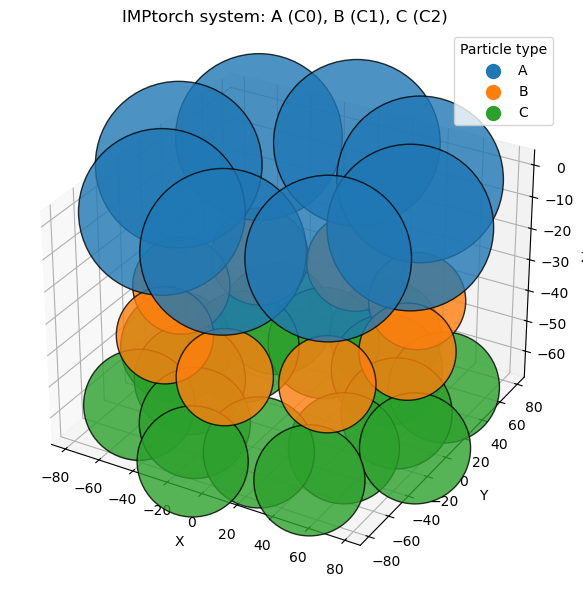

array_A = np.array([
    [65.50, 0, 0],
    [46.32, 46.32, 0],
    [-0.00, 65.50, 0],
    [-46.32, 46.32, 0],
    [-65.50, -0.00, 0],
    [-46.32, -46.32, 0],
    [0.00, -65.50, 0],
    [46.32, -46.32, 0],
])

array_B = np.array([
    [65.50, 0, -38.50],
    [46.32, 46.32, -38.50],
    [-0.00, 65.50, -38.50],
    [-46.32, 46.32, -38.50],
    [-65.50, -0.00, -38.50],
    [-46.32, -46.32, -38.50],
    [0.00, -65.50, -38.50],
    [46.32, -46.32, -38.50],
])

array_C = np.array([
    [53.86, 12.02, -64],  # pair 1
    [29.58, 46.58, -64],
    [-12.02, 53.86, -64],  # pair 2
    [-46.58, 29.58, -64],
    [-53.86, -12.02, -64],  # pair 3
    [-29.58, -46.58, -64],
    [12.02, -53.86, -64],  # pair 4
    [46.58, -29.58, -64],
    [77.14, -12.02, -64],  # pair 5
    [63.05, 46.05, -64],
    [12.02, 77.14, -64],  # pair 6
    [-46.05, 63.05, -64],
    [-77.14, 12.02, -64],  # pair 7
    [-63.05, -46.05, -64],
    [-12.02, -77.14, -64],  # pair 8
    [46.05, -63.05, -64],
])


In [6]:
import torch
import math
from dataclasses import dataclass
from typing import Dict
from IMPtorch.representations import SystemRepresentation

@dataclass
class SystemParameters:
    box_size: float = 600.0
    radii: Dict[str, float] = None
    tol: float = 0.5
    N_tetramers: int = 8
    vertical_drop: float = 25.5

    def __post_init__(self):
        if self.radii is None:
            self.radii = {'A': 24.0, 'B': 14.0, 'C': 16.0}
        self.AB = 38.5
        self.BC = 30.5

        # radius of circle on which A/B sit
        self.RA = 65.5

    def build_system(self) -> SystemRepresentation:
        N        = self.N_tetramers
        # 1) generate θ angles
        #theta    = torch.linspace(0, 2*math.pi, N, endpoint=False)
        theta = 2*math.pi * torch.arange(N, dtype=torch.float32) / N
        # 2) A coords: (N,3)
        A_xy     = self.RA * torch.stack([theta.cos(), theta.sin()], dim=1)
        A_xyz    = torch.cat([A_xy, torch.zeros(N,1)], dim=1)
        # 3) B directly below A
        B_xyz    = A_xyz.clone()
        B_xyz[:,2] -= self.AB
        # 4) compute horizontal δ for C placement
        #delta    = torch.sqrt(self.BC**2 - self.vertical_drop**2)
        # 4) compute horizontal δ for C placement as a Python float
        delta    = math.sqrt(self.BC**2 - self.vertical_drop**2)
        # 5) find best φ in torch (coarse search)
        phis     = torch.linspace(0, math.pi/2, 50)
        best_phi = None
        best_min = -1.0
        desired  = 2*self.radii['C'] + self.tol

        # helper to build C positions given φ
        def make_C(phi):
            # v vectors in plane
            v = delta * torch.stack([-theta.sin(), theta.cos()], dim=1)  # (N,2)
            # rotate v by φ
            R = torch.tensor([[phi.cos(), -phi.sin()],
                              [phi.sin(),  phi.cos()]])
            v2 = v @ R.T                                    # (N,2)
            zc = -self.AB - self.vertical_drop
            C1 = torch.cat([A_xy + v2, torch.full((N,1), zc)], dim=1)
            C2 = torch.cat([A_xy - v2, torch.full((N,1), zc)], dim=1)
            return torch.cat([C1, C2], dim=0)               # (2N,3)

        # search φ
        for φ in phis:
            C   = make_C(φ)
            # compute all pairwise C–C dists between different tetramers
            C1, C2 = C.unsqueeze(1), C.unsqueeze(0)           # broadcast (2N,2N,3)
            D     = torch.norm(C1 - C2, dim=2)                # (2N,2N)
            # mask self and intra‐tetramer pairs
            mask  = torch.eye(2*N, dtype=bool)
            D.masked_fill_(mask, float('inf'))
            m     = D.min().item()
            if m >= desired and m > best_min:
                best_min, best_phi = m, φ

        if best_phi is None:
            raise RuntimeError("no non‑overlapping φ found")

        C_xyz = make_C(best_phi)

        # 6) concatenate all particles: A, B, C
        xyz_ref = torch.cat([A_xyz, B_xyz, C_xyz], dim=0)    # (N_tot,3)
        N_tot   = xyz_ref.shape[0]

        # 7) define rigid_body: group each tetramer as one rigid body
        #    so particles [0..N-1]=A, [N..2N-1]=B, [2N..4N-1]=C
        #    we assign: rigid_body[i] = ⌊i/N⌋
        tet_idx = torch.arange(N_tot) // N

        # 8) super_rigid_body: e.g. group by type A vs B vs C
        type_ids = (
            torch.zeros(N, dtype=torch.long)                      # A’s = 0
            .tolist() +
            torch.ones(N, dtype=torch.long).tolist()               # B’s = 1
        )
        type_ids += (2*torch.ones(2*N, dtype=torch.long)).tolist()  # C’s = 2
        super_rb = torch.tensor(type_ids, dtype=torch.long)

        # 9) build SystemRepresentation
        system = SystemRepresentation(
            xyz_ref         = xyz_ref,
            rigid_body      = tet_idx,
            super_rigid_body= super_rb
        )

        # 10) attach per‑particle radii as a property (if supported)
        # You might have an API like system.register_property(...)
        try:
            system.register_property('radius',
                                     torch.tensor(
                                       [self.radii['A']]*N +
                                       [self.radii['B']]*N +
                                       [self.radii['C']]*2*N
                                     ))
        except AttributeError:
            # or just set as an attribute
            system.radius = torch.tensor(
                [self.radii['A']]*N +
                [self.radii['B']]*N +
                [self.radii['C']]*2*N
            )

        return system

# usage:
params = SystemParameters()
particles = params.build_system()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

# extract data from your SystemRepresentation
xyz = particles.xyz_ref.detach().cpu().numpy()         # (N_tot,3)
print("coordinates: ", xyz)
types = particles.super_rigid_body.cpu().numpy()       # 0=A, 1=B, 2=C
radii = particles.radius.cpu().numpy()                 # per‑particle radius

# define a color for each type
color_map = {0: "C0", 1: "C1", 2: "C2"}   # you can pick any matplotlib colors
colors = [color_map[t] for t in types]

# optionally scale marker size by radius (you may need to tune the scale factor)
size = (radii * 5)**2    # e.g. radius*5 and then squared for “area” 

# make the plot
fig = plt.figure(figsize=(6,6))
ax  = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    xyz[:,0], xyz[:,1], xyz[:,2],
    c=colors,
    s=size,
    alpha=0.8,
    edgecolor="k"
)

# make a legend
for t, label in enumerate(["A","B","C"]):
    ax.scatter([], [], [], c=color_map[t], label=label, s=100)
ax.legend(title="Particle type")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("IMPtorch system: A (C0), B (C1), C (C2)")
plt.tight_layout()
plt.show()

# Extract coordinates by particle type
N = 8  # Number of tetramers
array_A = xyz[:N]  # First N particles are type A
array_B = xyz[N:2*N]  # Next N particles are type B
array_C = xyz[2*N:]  # Remaining 2*N particles are type C

# Helper function to format numbers without decimal points when they're integers
def format_num(x):
    if abs(x - round(x)) < 1e-10:
        return f"{int(round(x))}"
    else:
        return f"{x:.2f}"

# Print coordinates in the desired format
print("array_A = np.array([")
for coord in array_A:
    print(f"    [{format_num(coord[0])}, {format_num(coord[1])}, {format_num(coord[2])}],")
print("])\n")

print("array_B = np.array([")
for coord in array_B:
    print(f"    [{format_num(coord[0])}, {format_num(coord[1])}, {format_num(coord[2])}],")
print("])\n")

print("array_C = np.array([")
for i in range(0, len(array_C), 2):
    print(f"    [{format_num(array_C[i][0])}, {format_num(array_C[i][1])}, {format_num(array_C[i][2])}],  # pair {i//2 + 1}")
    if i + 1 < len(array_C):
        print(f"    [{format_num(array_C[i+1][0])}, {format_num(array_C[i+1][1])}, {format_num(array_C[i+1][2])}],")
print("])")

# Create and print the dictionary
particle_dict = {'A': array_A, 'B': array_B, 'C': array_C}
#print("\nreturn {'A': array_A, 'B': array_B, 'C': array_C}")


In [7]:
# At this point, write a restraint function in IMPtorch, the class is going to contain pairwise restraint functions 
from IMPtorch.restraints import Restraint
import torch
from typing import Dict, List, Tuple, Set, Optional

class PairDistanceRestraint(Restraint):
    """
    Implements pairwise distance scoring between particle types,
    similar to the original calculate_score function but using the IMPTorch framework.
    """
    def __init__(self, 
                 particle_types: Dict[str, List[int]],  # Maps particle types to their indices in X
                 pair_distances: Dict[str, float],      # Target distances for each pair type (AA, AB, etc)
                 pair_sigmas: Dict[str, float],         # Sigma values for each pair type
                 exclusion_weight: float = 1.0,
                 pair_weight: float = 1.0,
                 excluded_pairs: Set[Tuple[str, int, str, int]] = None):
        super().__init__()
        self.particle_types = particle_types
        self.pair_distances = pair_distances
        self.pair_sigmas = pair_sigmas
        self.exclusion_weight = exclusion_weight
        self.pair_weight = pair_weight
        self.excluded_pairs = excluded_pairs or set()
        
        # Pre-define particle type pairs for scoring
        self.pair_types = [('A', 'A'), ('A', 'B'), ('B', 'C'), ('C', 'C')]
    
    def forward(self, X, **params):
        """Calculate score based on particle positions in X."""
        # 1. Excluded volume contribution
        exclusion_score = self.calculate_exclusion_score(X)
        
        # 2. Pairwise negative log-likelihood
        pair_score = self.calculate_pair_scores(X)
        
        # 3. Prior penalty (placeholder - would be implemented separately)
        prior_penalty = 0.0
        
        total_score = exclusion_score + pair_score + prior_penalty
        
        # Store the component scores for reporting
        self.last_scores = {
            'total': total_score,
            'exclusion': exclusion_score,
            'pair': pair_score,
            'prior': prior_penalty
        }
        
        return total_score
    
    def calculate_pair_scores(self, X):
        """Calculate pairwise scores between particle types."""
        pair_score = 0.0
        
        for type1, type2 in self.pair_types:
            pair_key = f"{type1}{type2}"
            
            if pair_key in self.pair_distances:
                # Get indices for the particle types
                indices1 = self.particle_types[type1]
                indices2 = self.particle_types[type2]
                
                # Skip if either particle type has no indices
                if not indices1 or not indices2:
                    continue
                
                # Get positions for these particle types
                pos1 = X.xyz_ref[indices1]
                pos2 = X.xyz_ref[indices2]
                
                # Get target distance and sigma for this pair type
                target_dist = self.pair_distances[pair_key]
                sigma = self.pair_sigmas[pair_key]
                
                # Calculate pairwise score matrix
                score_matrix = self.calculate_pair_score_matrix(
                    pos1, pos2, target_dist, sigma
                )
                
                # Mask diagonal for same-type pairs
                if type1 == type2:
                    # Create upper triangular mask (exclude diagonal)
                    mask = torch.triu(torch.ones_like(score_matrix), diagonal=1)
                    score_matrix = score_matrix * mask
                
                # Zero out excluded pairs if provided
                for idx1, global_idx1 in enumerate(indices1):
                    for idx2, global_idx2 in enumerate(indices2):
                        if (type1, global_idx1.item(), type2, global_idx2.item()) in self.excluded_pairs:
                            score_matrix[idx1, idx2] = torch.tensor(float('inf'))
                
                # First iterate through rows
                score_matrix_working = score_matrix.clone()
                for i in range(score_matrix_working.shape[0]):
                    # Skip if row is all inf
                    if torch.all(torch.isinf(score_matrix_working[i])):
                        continue
                    # Find minimum element and its index
                    min_index = torch.argmin(score_matrix_working[i])
                    # Set the transpose element to inf
                    score_matrix_working[min_index, i] = torch.tensor(float('inf'))
                
                # Then iterate through columns
                for j in range(score_matrix_working.shape[1]):
                    # Skip if column is all inf
                    if torch.all(torch.isinf(score_matrix_working[:, j])):
                        continue
                    # Find minimum element and its index
                    min_index = torch.argmin(score_matrix_working[:, j])
                    # Set the transpose element to inf
                    score_matrix_working[j, min_index] = torch.tensor(float('inf'))
                
                # Identify unique row/column pairs
                row_mins, row_indices = torch.min(score_matrix, dim=1)
                row_pairs = {(i, row_indices[i].item()) for i in range(len(indices1)) 
                            if not torch.isinf(row_mins[i])}
                
                col_mins, col_indices = torch.min(score_matrix, dim=0)
                col_pairs = {(col_indices[j].item(), j) for j in range(len(indices2))
                            if not torch.isinf(col_mins[j])}
                
                # Union of row and column pairs
                unique_pairs = row_pairs.union(col_pairs)
                
                # Accumulate score from the original matrix for these pairs
                for i, j in unique_pairs:
                    pair_score += self.pair_weight * score_matrix[i, j].item()
        
        return pair_score
    
    def calculate_pair_score_matrix(self, pos1, pos2, target_dist, sigma):
        """Calculate pairwise score matrix between two sets of positions."""
        # Calculate all pairwise distances (using broadcasting)
        diff = pos1.unsqueeze(1) - pos2.unsqueeze(0)  # shape: (n1, n2, 3)
        distances = torch.norm(diff, p=2, dim=2)      # shape: (n1, n2)
        
        # Calculate Gaussian negative log-likelihood
        score_matrix = ((distances - target_dist) ** 2) / (2 * sigma ** 2) + torch.log(2 * torch.pi * sigma ** 2)
        
        return score_matrix
    
    def calculate_exclusion_score(self, X):
        """Calculate exclusion volume score."""
        exclusion_score = 0.0
        
        # Get particle positions and radii
        positions = X.xyz_ref
        radii = X.radius if hasattr(X, 'radius') else torch.ones(positions.shape[0])
        
        # Calculate pairwise distances and check for overlaps
        n = positions.shape[0]
        for i in range(n):
            for j in range(i+1, n):
                dist = torch.norm(positions[i] - positions[j])
                min_dist = radii[i] + radii[j]
                
                # Apply penalty if particles overlap
                if dist < min_dist:
                    overlap = min_dist - dist
                    exclusion_score += self.exclusion_weight * (overlap ** 2)
        
        return exclusion_score
    
    def get_report(self, assemblies, model):
        """Return a report of the last calculated scores."""
        if hasattr(self, 'last_scores'):
            return self.last_scores
        return None

In [ ]:
# Example usage
# 1. Define your particle types and their indices in the SystemRepresentation
particle_indices = {
    'A': [0, 1, 2, 3],  # Indices of A particles in X.xyz_ref
    'B': [4, 5, 6, 7],  # Indices of B particles
    'C': [8, 9, 10, 11] # Indices of C particles
}

# 2. Define target distances for each pair type
pair_distances = {
    'AA': 48.0,
    'AB': 38.5,
    'BC': 30.5,
    'CC': 32.0
}

# 3. Define sigma values for each pair type
pair_sigmas = {
    'AA': 0.7,
    'AB': 0.45,
    'BC': 0.35, 
    'CC': 0.65
}

# 4. Create the restraint
pair_restraint = PairDistanceRestraint(
    particle_types=particle_indices,
    pair_distances=pair_distances,
    pair_sigmas=pair_sigmas,
    exclusion_weight=1.0,
    pair_weight=1.0
)

# 5. Add to a RestraintSet if needed
from IMPtorch.restraints import RestraintSet
restraint_set = RestraintSet([pair_restraint], X=particles)